In [15]:
import sys
import os
import torch
sys.path.append(os.path.abspath('../'))

from src.models.single_network import SingleNetwork
from src.models.mc_dropout import MCDropout
from src.models.deep_ensemble import DeepEnsemble
from src.training.trainer import ModelTrainer
from src.processing.preprocess import get_dataloaders_for_sipakmed, getdataframe_for_sipakmed
from src.processing.loading import load_image_folder
from src.utils.visualisation import plot_performance_curves, plot_metrics_performance, ReliabilityPlotter
import pandas as pd
import matplotlib.pyplot as plt


`{im_Dyskeratotic: 0, im_Koilocytic: 1, im_Metaplasticimage_path: 2, im_Parabasal:3, im_Superficial-Intermediate: 4}`

In [2]:
train_loader, val_loader, cal_loader, test_loader = get_dataloaders_for_sipakmed(batch_size=32, num_workers=4, model_type="resnet")


df_all = getdataframe_for_sipakmed(train_loader, val_loader, cal_loader, test_loader)
df_all

,subset,image_path,label
0,train,/home/conite/Documents/STAGE/HybridUncertainty...,1
1,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
2,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
3,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
4,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
...,...,...,...
4044,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4045,test,/home/conite/Documents/STAGE/HybridUncertainty...,4
4046,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4047,test,/home/conite/Documents/STAGE/HybridUncertainty...,3


In [9]:
single_net = SingleNetwork(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

mcdropout = MCDropout(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

deepensemble = DeepEnsemble(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)


**1.0 Evaluation**

In [11]:
# single_net.train(epochs=50, model_path='single_net_resnet_sipakmed.pth')
single_net.load('../experiments/results/sipakmed/output_single_resnet50_sipakmed.pth')
results_sn = single_net.evaluate()
print(f"Accuracy: {results_sn['accuracy']} | F1: {results_sn['f1_score']} | Precision: {results_sn['precision']} | Recall: {results_sn['recall']} | Brier: {results_sn['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [12]:
mcdropout.load('../experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.pth')
results_mcd = mcdropout.evaluate()
print(f"Accuracy: {results_mcd['accuracy']} | F1: {results_mcd['f1_score']} | Precision: {results_mcd['precision']} | Recall: {results_mcd['recall']} | Brier: {results_mcd['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [13]:
deepensemble.load([
    f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.pth" for i in range(5)
])
deepensemble_results = deepensemble.evaluate()
print(f"Accuracy: {deepensemble_results['accuracy']} | F1: {deepensemble_results['f1_score']} | Precision: {deepensemble_results['precision']} | Recall: {deepensemble_results['recall']} | Brier: {deepensemble_results['brier_score']} ")


/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/deep_ensemble.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=

Model 1 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_0.pth
Model 2 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_1.pth
Model 3 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_2.pth
Model 4 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_3.pth
Model 5 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_4.pth

🔎 Predicting with ensemble member 1/5



🔎 Predicting with ensemble member 2/5



🔎 Predicting with ensemble member 3/5



🔎 Predicting with ensemble member 4/5



🔎 Predicting with ensemble member 5/5


Accuracy: 0.9917763157894737 | F1: 0.9917693469346797 | Precision: 0.9917760834820101 | Recall: 0.9917763157894737 | Brier: 0.017302077263593674 


In [ ]:

ENSEMBLE_SIZE = 5
path_results = {
    'single': "/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_single_resnet50_sipakmed.json",
    'mc_dropout': "/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.json",
    'deep_ensemble': [
        f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.json"
        for i in range(ENSEMBLE_SIZE)
    ]
}

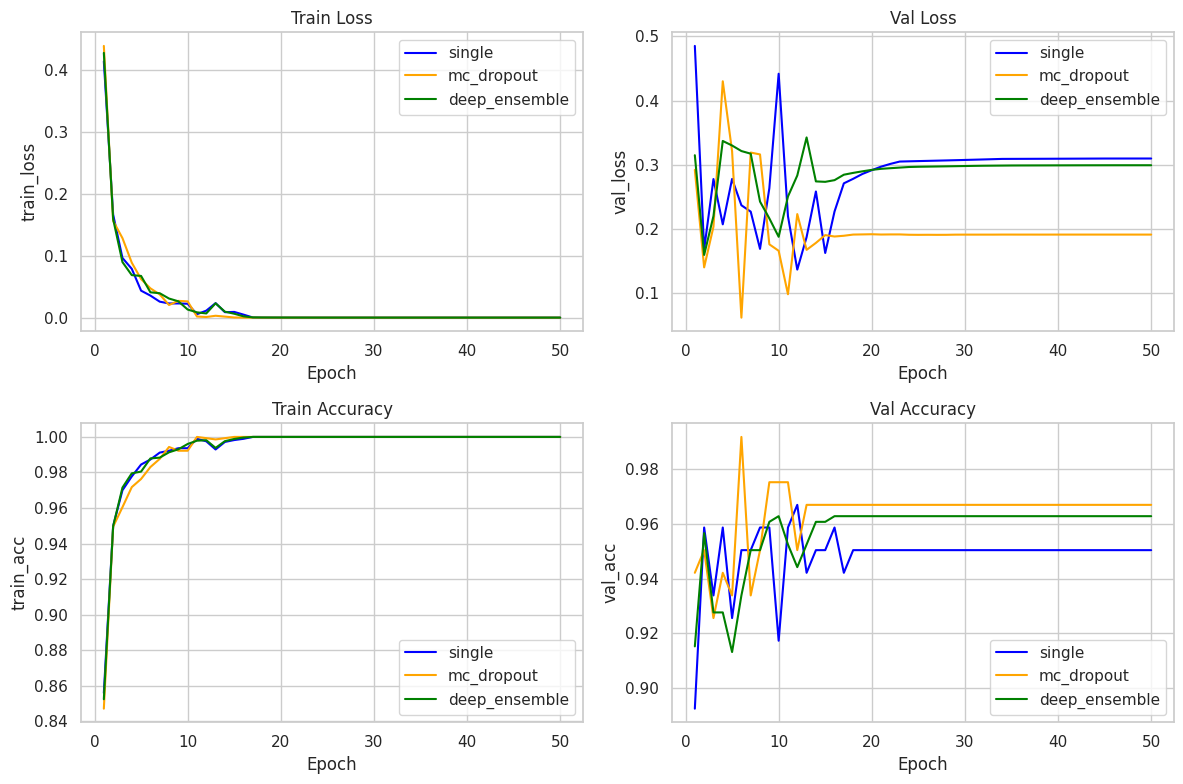

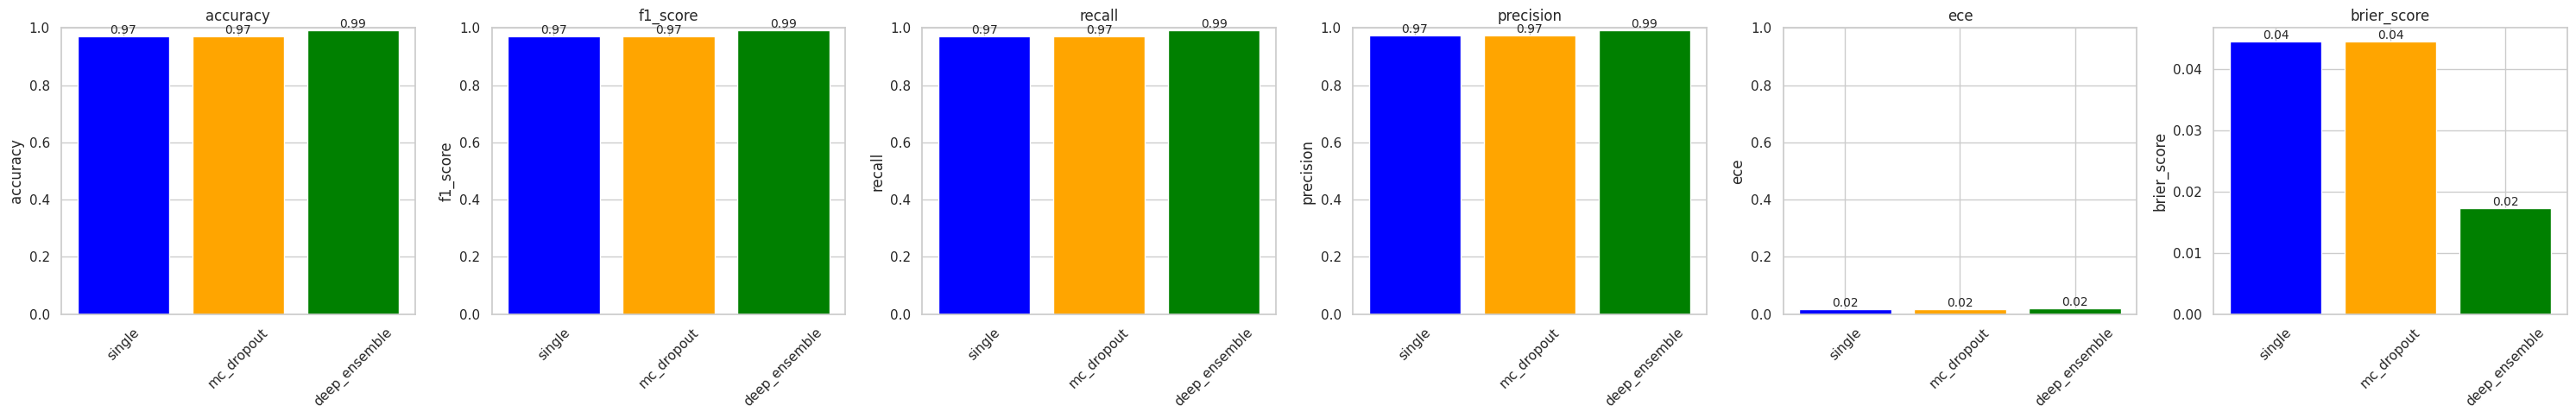

In [ ]:
ENSEMBLE_SIZE = 5
path_results = {
    'single': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_single_resnet50_sipakmed.json"),
    
    'mc_dropout': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.json"),
    'deep_ensemble': [
        os.path.join(f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.json") 
        for i in range(1,ENSEMBLE_SIZE)
    ]
}

gather_results = {
    'single': results_sn,
    'mc_dropout': results_mcd,
    'deep_ensemble': deepensemble_results
}


plot_performance_curves(path_results=path_results)
plot_metrics_performance(gather_results)

In [ ]:
approaches_data = {
    'single': (results_sn['single']['y_true'], results_sn['single']['y_probas']),
    'mc_dropout': (pipeline.test_results['mc_dropout']['y_true'], pipeline.test_results['mc_dropout']['y_probas']),
    'deep_ensemble': (pipeline.test_results['deep_ensemble']['y_true'], pipeline.test_results['deep_ensemble']['y_probas'])
}

plotter = ReliabilityPlotter(approaches_data)
plotter.plot_all_approaches(n_bins=10)